<a href="https://colab.research.google.com/github/244107020170-png/machine-learning/blob/main/lab2_naivebayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import make_classification

# Create dummy data
# The output of make_classification consists of feature data X and labels y
# The labels y will be encoded (numerical) data
X, y = make_classification(
    n_samples=30,
    n_features=2,
    n_classes=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    shuffle=False
)

# By default, make_classification produces float values
# We need to convert them to discrete form

# Take the absolute value of the values
X = np.absolute(X)

# Round values to two decimal places
# Multiply by 100 so that there are no decimal points
X = np.round(X, 2) * 100

# Convert to integer type
X = X.astype(int)

# Check the result
print(X)
print(y)

[[ 96  82]
 [107 221]
 [ 98 121]
 [102 164]
 [ 93  91]
 [114 155]
 [113 183]
 [103  80]
 [258 260]
 [252 243]
 [ 41  22]
 [103 133]
 [ 38  38]
 [127 157]
 [ 24  43]
 [133 167]
 [ 95  94]
 [ 83 121]
 [118  73]
 [ 81 164]
 [ 82 363]
 [160 115]
 [138  98]
 [ 37  34]
 [236 215]
 [128  23]
 [ 16  64]
 [152 171]
 [132 153]
 [157 128]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [2]:
print(X.shape)
print(y.shape)

(30, 2)
(30,)


In [3]:
import pandas as pd

# Reshape label y into 2D
y_new = y.reshape(len(y), 1)

# Concatenate features X and label y
data = np.concatenate((X, y_new), axis=1)

# Define column names
nama_kolom = ['Feature 1', 'Feature 2', 'Label']

# Create DataFrame
df = pd.DataFrame(data, columns=nama_kolom)

# Inspect the DataFrame
df.head()

,Feature 1,Feature 2,Label
0,96,82,0
1,107,221,0
2,98,121,0
3,102,164,0
4,93,91,0


In [4]:
# Define label names
labels = {
    1: 'Class A',
    0: 'Class B'
}

# Copy the DataFrame
df_label = df.copy()

# Replace labels
df_label['Label'] = df_label['Label'].map(labels)

# Inspect the df_label DataFrame
df_label.head()

,Feature 1,Feature 2,Label
0,96,82,Class B
1,107,221,Class B
2,98,121,Class B
3,102,164,Class B
4,93,91,Class B


/tmp/ipykernel_1444/3711264787.py:12: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Class A')
/tmp/ipykernel_1444/3711264787.py:13: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Class B')


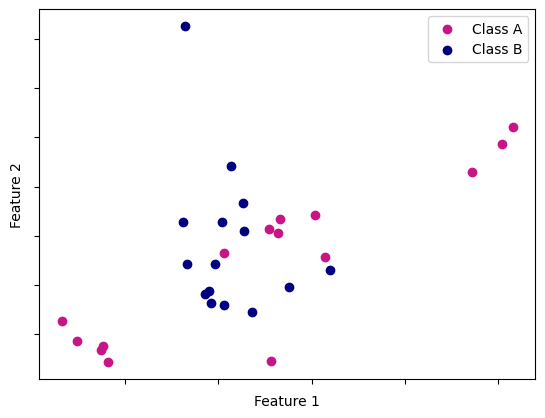

In [5]:
import matplotlib.pyplot as plt

# Define colors for each class
colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

# Group labels by class name
gb = df_label.groupby(['Label'])

class_a = gb.get_group('Class A')
class_b = gb.get_group('Class B')

# Plot
plt.scatter(
    x=class_a['Feature 1'],
    y=class_a['Feature 2'],
    c=colors['class_a']
)

plt.scatter(
    x=class_b['Feature 1'],
    y=class_b['Feature 2'],
    c=colors['class_b']
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(['Class A', 'Class B'])

plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])

plt.show()

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Instantiate a MultinomialNB object
mnb = MultinomialNB()

# Split training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=30
)

# Fit the model
mnb.fit(X_train, y_train)

# Predict on training data
y_train_pred = mnb.predict(X_train)

# Evaluate training accuracy
acc_train = accuracy_score(y_train, y_train_pred)

# Predict test data
y_test_pred = mnb.predict(X_test)

# Evaluate test accuracy
acc_test = accuracy_score(y_test, y_test_pred)

# Print evaluation results
print(f'Training accuracy: {acc_train}')
print(f'Test accuracy: {acc_test}')

Training accuracy: 0.5714285714285714
Test accuracy: 0.6666666666666666


In [7]:
from sklearn.naive_bayes import GaussianNB

# Instantiate a Gaussian object
gnb = GaussianNB()

# Use the same training and testing split
# as used for the multinomial model

# Fit the model
gnb.fit(X_train, y_train)

# Predict on training data
y_train_pred_gnb = gnb.predict(X_train)

# Evaluate training accuracy
acc_train_gnb = accuracy_score(
    y_train,
    y_train_pred_gnb
)

# Predict test data
y_test_pred_gnb = gnb.predict(X_test)

# Evaluate the model using accuracy
acc_test_gnb = accuracy_score(
    y_test,
    y_test_pred_gnb
)

# Print evaluation results
print(f'Training accuracy (Gaussian): {acc_train_gnb}')
print(f'Test accuracy (Gaussian): {acc_test_gnb}')

Training accuracy (Gaussian): 0.8571428571428571
Test accuracy (Gaussian): 0.6666666666666666
